In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pickle
import json
import tfidf
import seaborn as sns
import os


In [2]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def softmax(z, axis=1):
    exp_z = np.exp(z - np.max(z, axis=axis, keepdims=True))
    return exp_z / np.sum(exp_z, axis=axis, keepdims=True)

def one_hot(y, num_classes):
    onehot = np.zeros((len(y), num_classes))

    for row, col in enumerate(y):
        onehot[row, col] = 1

    return onehot

In [3]:
class LogisticRegression:

    def __init__(self,name,language_to_idx,idx_to_language):

        self.w = None
        self.b = None
        self.name = name

        self.num_classes = None
        self.num_features = None

        self.loss_history = []
        self.val_loss_history = []

        self.language_to_idx = language_to_idx
        self.idx_to_language = idx_to_language

        self.confusion_matrix = None
        self.class_scores = {}

        self.accuracy_score = None
        self.precision_score = None
        self.recall_score = None
        self.f1_score = None


    def fit(self,x,y,word_to_idx,x_val=None,y_val=None,epochs=100,learning_rate=0.1):

        self.num_classes = len(np.unique(y))
        self.num_features = len(word_to_idx)
        self.w = np.zeros((self.num_classes,self.num_features),dtype=np.float32)
        self.b = np.zeros(self.num_classes,dtype=np.float32)

        processed_x = []

        for sentence in x:

            indices = np.fromiter(sentence.keys(),dtype=np.intp)
            values = np.fromiter(sentence.values(),dtype=np.float32)
            processed_x.append((indices,values))

        y = np.asarray(y,dtype=np.intp)
        
        processed_x_val = []

        if x_val is not None:

            for sentence in x_val:

                indices = np.fromiter(sentence.keys(),dtype=np.intp)
                values = np.fromiter(sentence.values(),dtype=np.float32)
                processed_x_val.append((indices,values))

        if y_val is not None:

            y_val = np.asarray(y_val,dtype=np.intp)

        self.loss_history = []
        self.val_loss_history = []

        for epoch in range(epochs):

            total_loss = 0.0
            total_val_loss = 0.0

            for idx, (word_indices,values) in enumerate(processed_x):

                z = (self.b+self.w[:, word_indices] @ values)
                z_max = np.max(z)
                exp_z = np.exp(z - z_max)
                probs = (exp_z/np.sum(exp_z))

                target = y[idx]

                total_loss -= np.log(probs[target] + 1e-15)

                error = probs.copy()
                error[target] -= 1.0

                self.w[:, word_indices] -= (learning_rate*error[:, None]*values[None, :])
                self.b -= (learning_rate*error)

            if ( x_val is not None and y_val is not None):

                for idx, (word_indices,values) in enumerate(processed_x_val):

                    z = (self.b+self.w[:, word_indices] @ values)
                    z_max = np.max(z)
                    exp_z = np.exp(z - z_max)
                    probs = (exp_z/np.sum(exp_z))

                    target = y_val[idx]

                    total_val_loss -= np.log(probs[target] + 1e-15)

            train_N = len(x)
            val_N = (len(x_val) if x_val is not None else 1 )
            train_loss = (total_loss / train_N)
            val_loss = (total_val_loss / val_N if x_val is not None else 0.0 )

            if (epoch % 10 == 0 or epoch == epochs - 1):

                print(f"Epoch {epoch + 1}/{epochs}, "f"Training Loss = {train_loss:.4f}, "f"Validation Loss = {val_loss:.4f}")

            self.loss_history.append(train_loss)
            self.val_loss_history.append(val_loss)


    def predict(self, x):

        predictions = []

        for sentence in x:

            z = self.b.copy()

            for word, value in sentence.items():

                z += (self.w[:, int(word)]*value)

            probs = softmax(z,axis=0)
            y_pred = np.argmax(probs)
            predictions.append(y_pred)

        return np.array(predictions)


    def evaluate(self,x,y_true,name="Model"):

        y_pred = self.predict(x)

        classes = np.arange(self.num_classes)
        self.confusion_matrix = np.zeros((self.num_classes,self.num_classes),dtype=np.int64)

        for true_label, pred_label in zip(y_true,y_pred):

            self.confusion_matrix[true_label,pred_label] += 1

        accuracy = np.mean(y_true == y_pred)

        self.class_scores = {}
        precision_list = []
        recall_list = []
        f1_list = []

        total_samples = np.sum(
            self.confusion_matrix
        )

        for class_idx in classes:

            tp = self.confusion_matrix[class_idx,class_idx]
            fp = (np.sum(self.confusion_matrix[:,class_idx])-tp)
            fn = (np.sum(self.confusion_matrix[class_idx,:])-tp)
            tn = (total_samples-tp-fp-fn)

            precision = (tp / (tp + fp)if (tp + fp) > 0 else 0.0)
            recall = (tp / (tp + fn)if (tp + fn) > 0 else 0.0)

            f1 = (2*precision*recall/(precision + recall) if (precision + recall) > 0 else 0.0)
            class_accuracy = ((tp + tn)/ total_samples if total_samples > 0 else 0.0)
            support = tp + fn
            language = self.idx_to_language[class_idx]

            self.class_scores[
                language
            ] = {
                "class_index":int(class_idx),
                "accuracy":class_accuracy,
                "precision":precision,
                "recall":recall,
                "f1":f1,
                "support":int(support)
            }

            precision_list.append(precision)
            recall_list.append(recall)
            f1_list.append(f1)

        self.accuracy_score = accuracy
        self.precision_score = np.mean(precision_list)
        self.recall_score = np.mean(recall_list)
        self.f1_score = np.mean(f1_list)

        return {
            "accuracy":self.accuracy_score,
            "precision":self.precision_score,
            "recall":self.recall_score,
            "f1":self.f1_score
        }


    def predict_sentence(self,sentences,idf_values,word_to_idx):

        tfidf_matrix = (
            tfidf.calculate_tfidf(
                sentences=sentences,
                idf_values=idf_values,
                word_to_idx=word_to_idx
            )
        )

        y_pred = self.predict(tfidf_matrix.values())

        ans = pd.DataFrame({
            "predicted language":
                [
                    self.idx_to_language[idx]
                    for idx in y_pred
                ],
            "sentence":
                sentences
        })

        return ans


    def save_model(self,filepath):

        with open(filepath,"wb") as f:
            pickle.dump(self,f)

        print(f"Model saved to: {filepath}")


    @staticmethod
    def load_model(filepath):

        with open(filepath,"rb") as f:
            model = pickle.load(f)

        print(f"Model loaded from: {filepath}")

        return model


    def save_evaluation_csv(self,filepath):

        row = {"name": self.name,
               "accuracy":self.accuracy_score,
               "precision":self.precision_score,
               "recall":self.recall_score,
               "f1":self.f1_score,
               "confusion_matrix":json.dumps(self.confusion_matrix.tolist()),
               "class_scores":json.dumps(self.class_scores)
        }

        df = pd.DataFrame([row])
        df.to_csv(filepath,index=False)
        print(f"Evaluation saved to: {filepath}")

        return row



In [4]:
def prepair_data(train_df,language_to_idx=None):
    languages = train_df["language"].unique()

    if language_to_idx is None:
        language_to_idx = {  language: i for i, language in enumerate(languages) }

    y = np.array([

        language_to_idx[
            language
        ]

        for language
        in train_df["language"]])

    X = train_df["text"].apply(lambda x:{ int(k): float(v) for k, v in json.loads(x).items() } )

    return (X,y,language_to_idx)



In [5]:


def make_model(combination_dir,combination_name,type="unnormalized",epochs=50,learning_rate=0.1):

    print("\n")
    print("=" * 100)
    print(
        f"WORKING ON: {combination_name}"
    )
    print("=" * 100)

    train_path = os.path.join(combination_dir,"train_df.csv")
    val_path = os.path.join(combination_dir,"val_df.csv")
    test_path = os.path.join(combination_dir,"test_df.csv")    
    word_path = os.path.join(combination_dir,"word_to_idx.pkl")
    idf_path = os.path.join(combination_dir,"idf_"+type+".pkl")


    train_df = pd.read_csv(train_path)
    val_df = pd.read_csv(val_path)
    test_df = pd.read_csv(test_path)

    with open(word_path,"rb") as f:
        word_to_idx = pickle.load(f)

    idf_values = None
    
    with open(idf_path,"rb") as f:
        idf_values = pickle.load(f)

    print("Train shape:",train_df.shape)
    print("Validation shape:",val_df.shape)
    print("Test shape:",test_df.shape)
    print("Vocabulary size:",len(word_to_idx))

    X_train, y_train, language_to_idx = (prepair_data(train_df))
    X_val, y_val, _ = (prepair_data(val_df,language_to_idx))
    X_test, y_test, _ = (prepair_data(test_df,language_to_idx))

    idx_to_language = {
        idx: language
        for language, idx
        in language_to_idx.items()
    }

    model = LogisticRegression(combination_name,language_to_idx,idx_to_language)

    model.fit(X_train,y_train,word_to_idx,x_val=X_val,y_val=y_val,epochs=epochs,learning_rate=learning_rate)

    result = model.evaluate(X_test,y_test)
    print("\nTest Results:")

    print(f"Accuracy : {result['accuracy']:.6f}")
    print(f"Precision: {result['precision']:.6f}")
    print(f"Recall   : {result['recall']:.6f}")
    print(f"F1       : {result['f1']:.6f}")

    epochs_range = range(1,len(model.loss_history) + 1)

    plt.figure(figsize=(10, 6))
    plt.plot(epochs_range,model.loss_history,label="Training Loss")
    plt.plot(epochs_range,model.val_loss_history,label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(combination_name)
    plt.legend()

    plt.grid(True)
    plt.tight_layout()

    loss_path = os.path.join(combination_dir,"loss_curve.png")
    plt.savefig(loss_path,dpi=300,bbox_inches="tight")
    plt.show()

    plt.close()

    labels = ['Manipuri (Meitei)','Khasi','Bodo','English','Telugu','Urdu','Sindhi','Hindi','Malayalam','Dogri','Kannada','Bengali','Tamil','Sanskrit','Santali','Nepali','Punjabi','Maithili','Odia','Goan Konkani','Gujar','Assamese','Marathi','Kashmiri']

    if len(labels) != model.num_classes:

        labels = [
            model.idx_to_language[i]
            for i
            in range(model.num_classes)
        ]

    plt.figure(figsize=(18, 15))

    sns.heatmap(
        model.confusion_matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.title(f"Confusion Matrix - {combination_name}")

    plt.xticks(rotation=90)
    plt.yticks(rotation=0)

    plt.tight_layout()

    cm_path = os.path.join(combination_dir,"confusion_matrix.png")

    plt.savefig(cm_path,dpi=300,bbox_inches="tight")

    plt.show()
    plt.close()

    evaluation_path = os.path.join(combination_dir,"evaluation.csv")

    summary = model.save_evaluation_csv(evaluation_path)

    model_path = os.path.join(combination_dir,"model.pkl")

    model.save_model(model_path)

    result = {"name":combination_name,"accuracy":float(model.accuracy_score),"precision":float(model.precision_score),"recall":float(model.recall_score),"f1":float(model.f1_score )}

    # del model
    # del X_train
    # del X_val
    # del X_test
    # del y_train
    # del y_val
    # del y_test
    # del train_df
    # del val_df
    # del test_df
    # del word_to_idx
    # del idf_values

    return result


Vocabulary file: D:/LLM/LAB 1/Dataset/vocab/metadata/language_vocab_freq_ngram.pkl
Vocabulary type: language_vocab_freq_ngram
TF-IDF directory: D:/LLM/LAB 2/tfidf/full vocab


WORKING ON: language_vocab_freq_ngram_tf_unnormalized_idf_unnormalized


Train shape: (19200, 2)
Validation shape: (2400, 2)
Test shape: (2400, 2)
Vocabulary size: 457668
Epoch 1/100, Training Loss = 3.7903, Validation Loss = 2.9252
Epoch 11/100, Training Loss = 0.0627, Validation Loss = 2.4454
Epoch 21/100, Training Loss = 0.0318, Validation Loss = 2.3438
Epoch 31/100, Training Loss = 0.0228, Validation Loss = 2.3403
Epoch 41/100, Training Loss = 0.0231, Validation Loss = 2.3413
Epoch 51/100, Training Loss = 0.0221, Validation Loss = 2.3422
Epoch 61/100, Training Loss = 0.0221, Validation Loss = 2.3430
Epoch 71/100, Training Loss = 0.0230, Validation Loss = 2.3437
Epoch 81/100, Training Loss = 0.0219, Validation Loss = 2.3443
Epoch 91/100, Training Loss = 0.0219, Validation Loss = 2.3449
Epoch 100/100, Training Loss = 0.0218, Validation Loss = 2.3454

Test Results:
Accuracy : 0.920417
Precision: 0.921807
Recall   : 0.920417
F1       : 0.920721


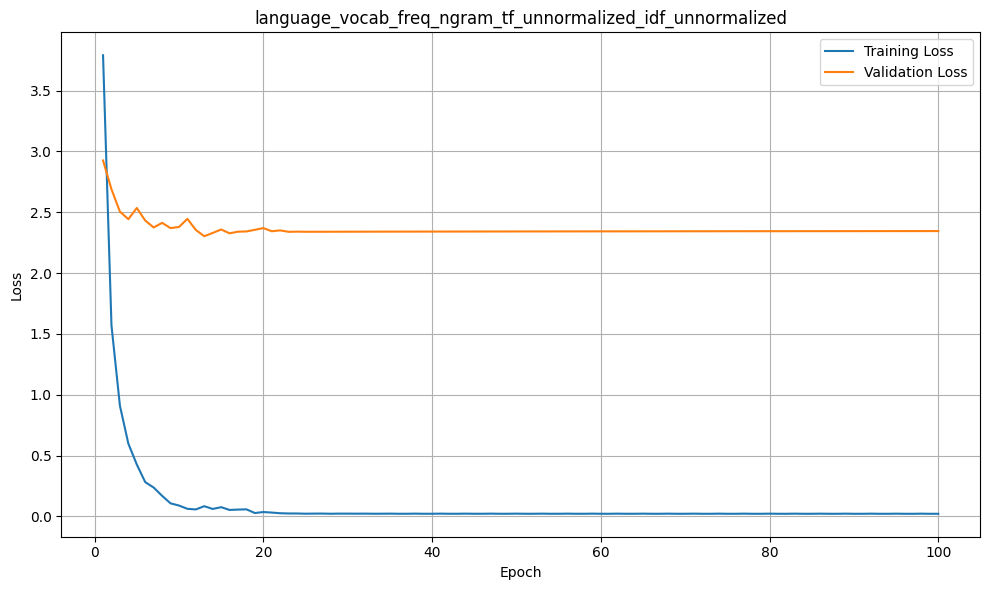

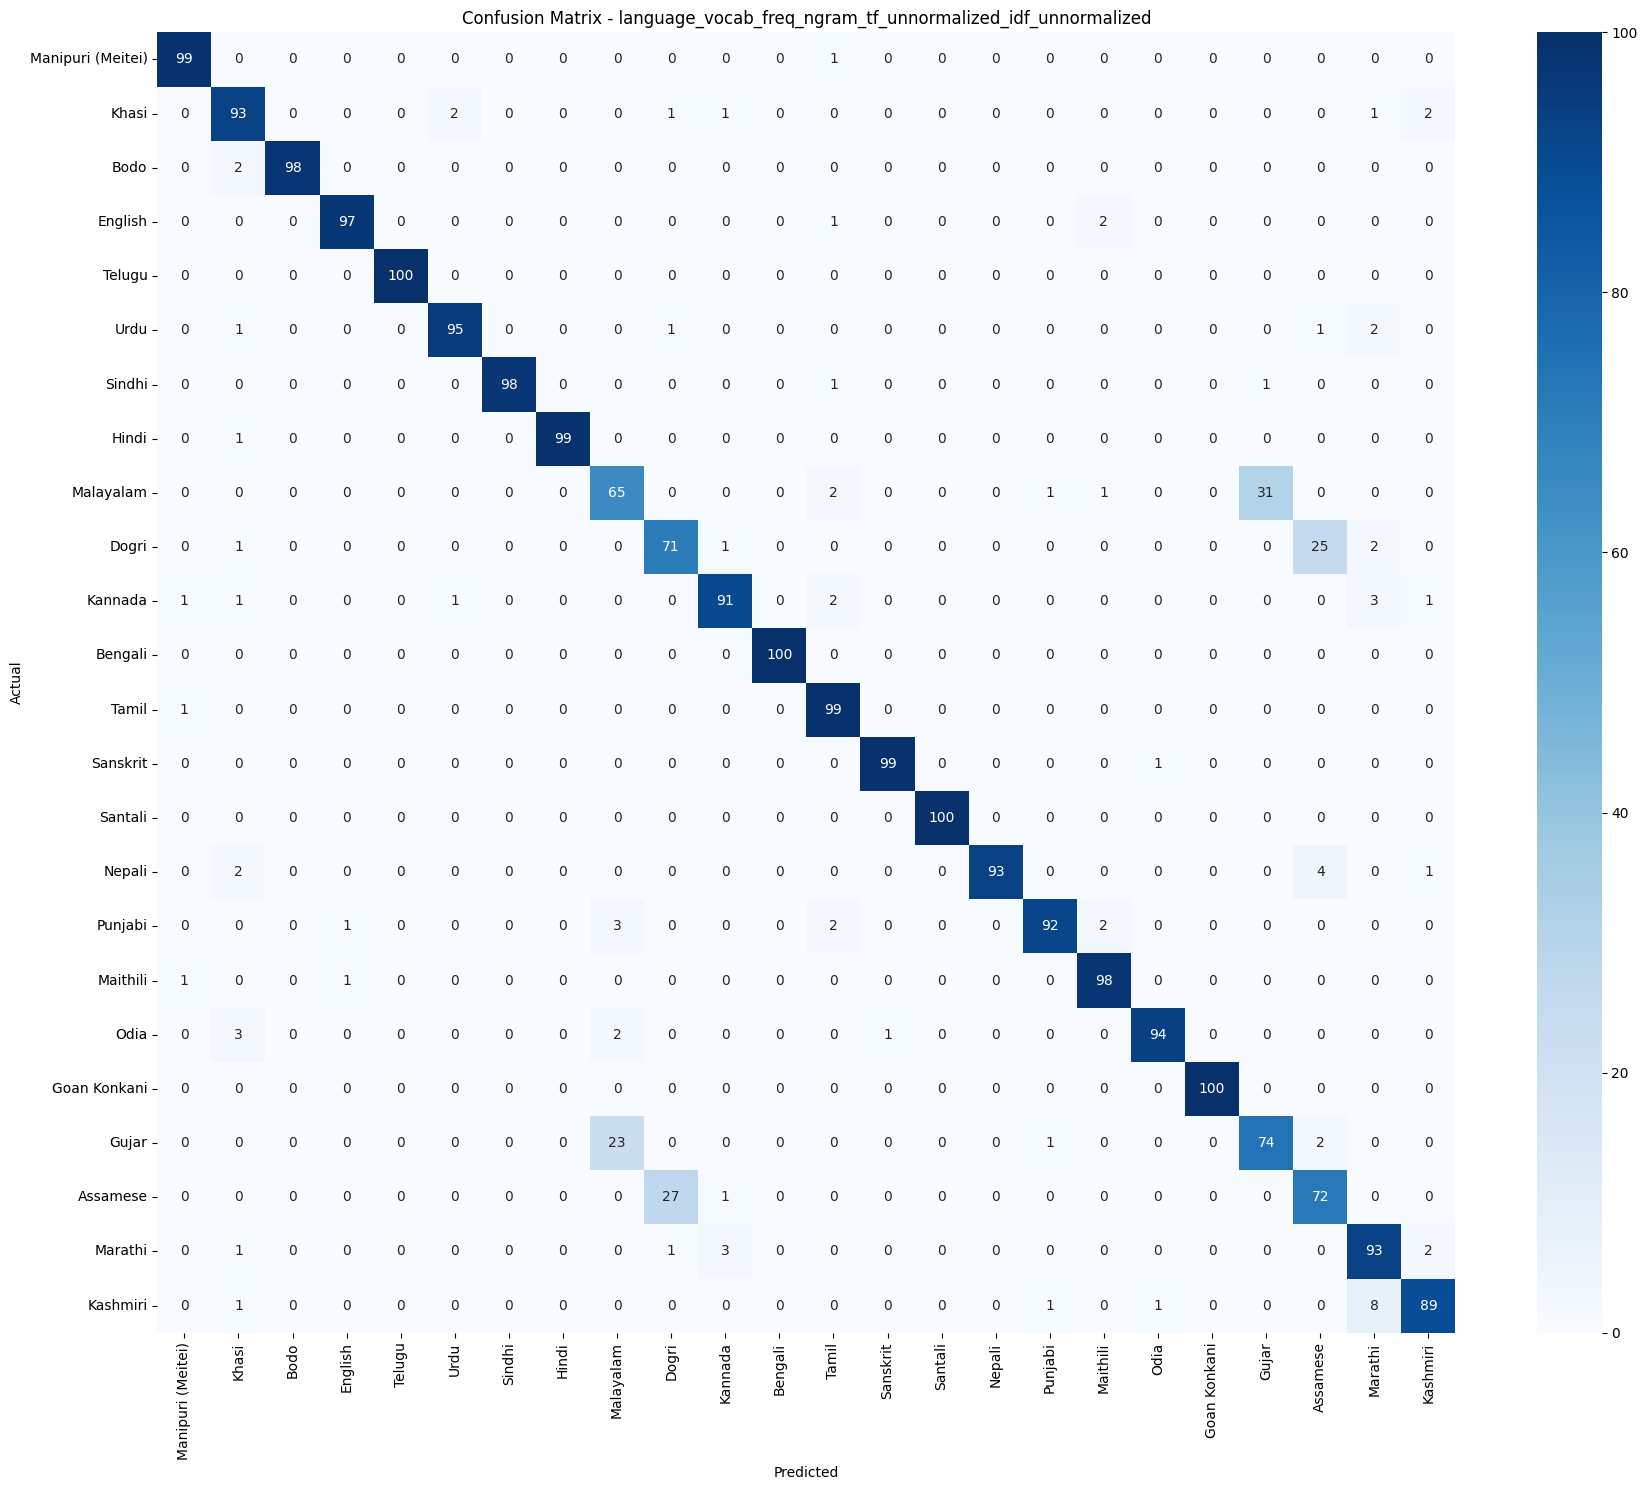

Evaluation saved to: D:/LLM/LAB 2/tfidf/full vocab\tf_unnormalized_idf_unnormalized\evaluation.csv
Model saved to: D:/LLM/LAB 2/tfidf/full vocab\tf_unnormalized_idf_unnormalized\model.pkl


WORKING ON: language_vocab_freq_ngram_tf_unnormalized_idf_normalized
Train shape: (19200, 2)
Validation shape: (2400, 2)
Test shape: (2400, 2)
Vocabulary size: 457668
Epoch 1/100, Training Loss = 0.7777, Validation Loss = 0.5937
Epoch 11/100, Training Loss = 0.0233, Validation Loss = 0.5321
Epoch 21/100, Training Loss = 0.0158, Validation Loss = 0.5361
Epoch 31/100, Training Loss = 0.0131, Validation Loss = 0.5401
Epoch 41/100, Training Loss = 0.0116, Validation Loss = 0.5443
Epoch 51/100, Training Loss = 0.0105, Validation Loss = 0.5482
Epoch 61/100, Training Loss = 0.0098, Validation Loss = 0.5520
Epoch 71/100, Training Loss = 0.0093, Validation Loss = 0.5557
Epoch 81/100, Training Loss = 0.0088, Validation Loss = 0.5591
Epoch 91/100, Training Loss = 0.0085, Validation Loss = 0.5624
Epoch 100/100,

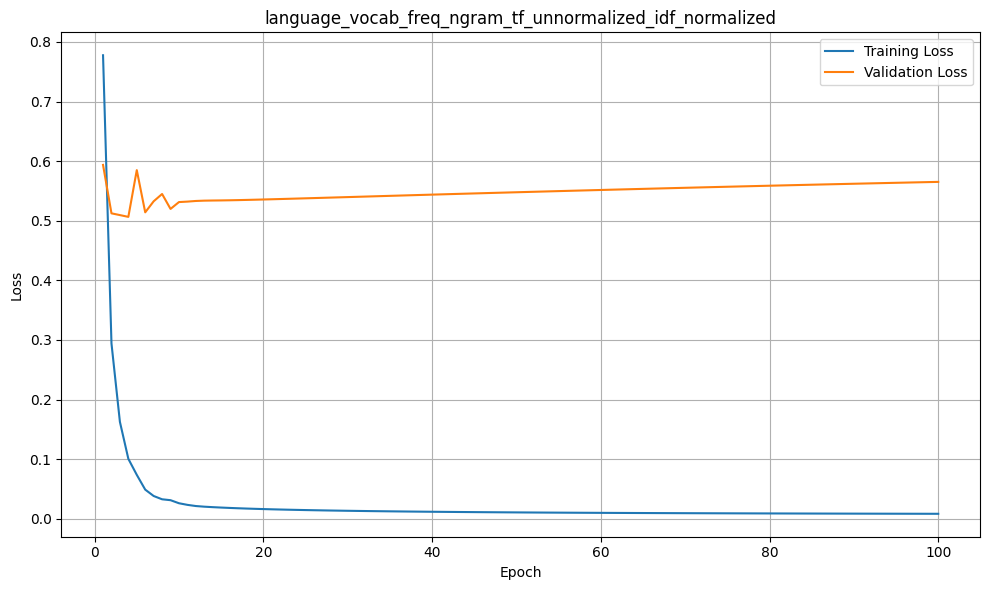

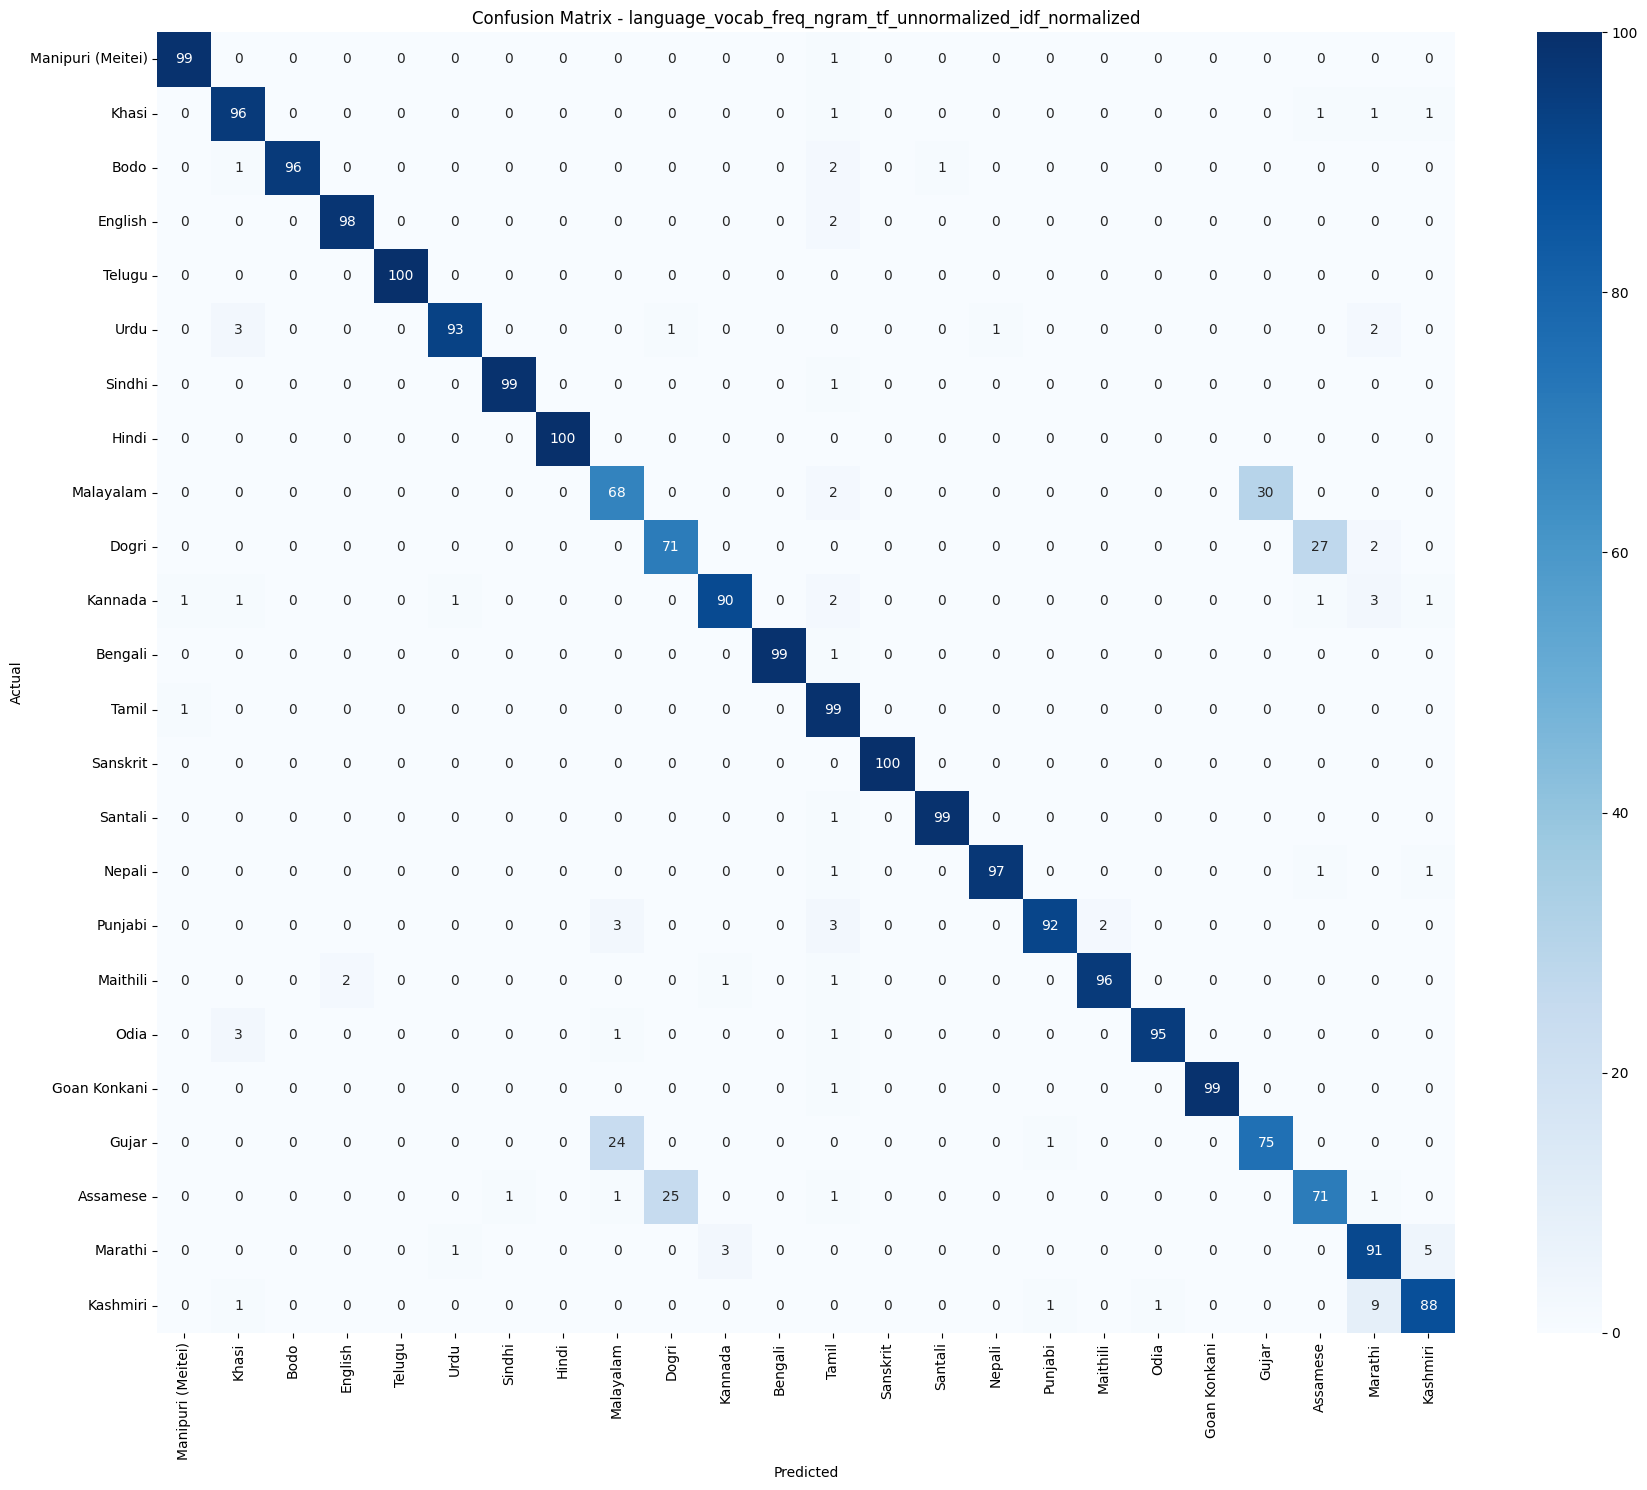

Evaluation saved to: D:/LLM/LAB 2/tfidf/full vocab\tf_unnormalized_idf_normalized\evaluation.csv
Model saved to: D:/LLM/LAB 2/tfidf/full vocab\tf_unnormalized_idf_normalized\model.pkl


WORKING ON: language_vocab_freq_ngram_tf_total_idf_unnormalized
Train shape: (19200, 2)
Validation shape: (2400, 2)
Test shape: (2400, 2)
Vocabulary size: 457668
Epoch 1/100, Training Loss = 2.4655, Validation Loss = 1.8364
Epoch 11/100, Training Loss = 0.3228, Validation Loss = 0.3627
Epoch 21/100, Training Loss = 0.2187, Validation Loss = 0.2790
Epoch 31/100, Training Loss = 0.1762, Validation Loss = 0.2481
Epoch 41/100, Training Loss = 0.1514, Validation Loss = 0.2317
Epoch 51/100, Training Loss = 0.1346, Validation Loss = 0.2214
Epoch 61/100, Training Loss = 0.1223, Validation Loss = 0.2145
Epoch 71/100, Training Loss = 0.1127, Validation Loss = 0.2095
Epoch 81/100, Training Loss = 0.1050, Validation Loss = 0.2058
Epoch 91/100, Training Loss = 0.0986, Validation Loss = 0.2029
Epoch 100/100, Training

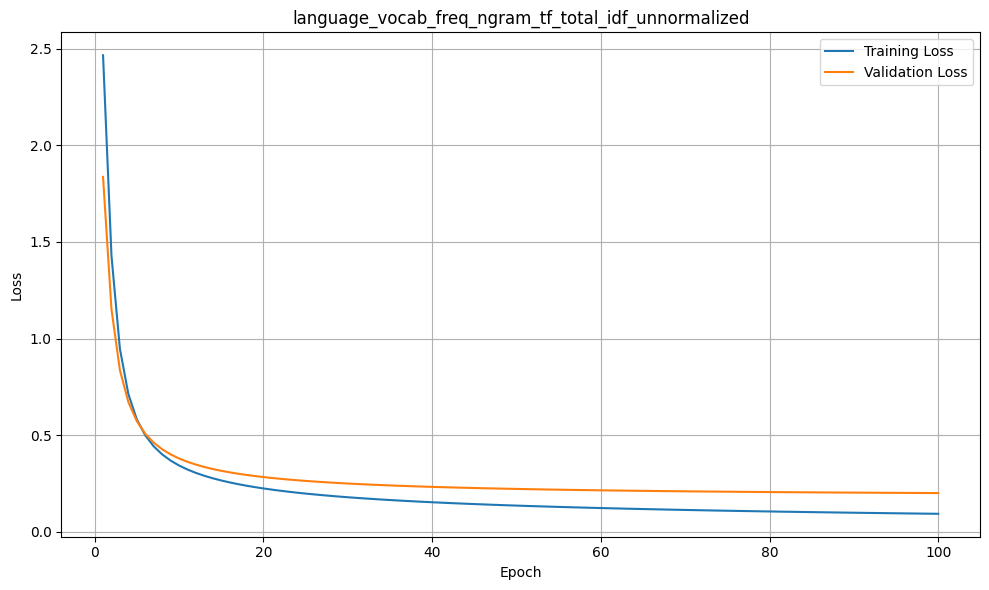

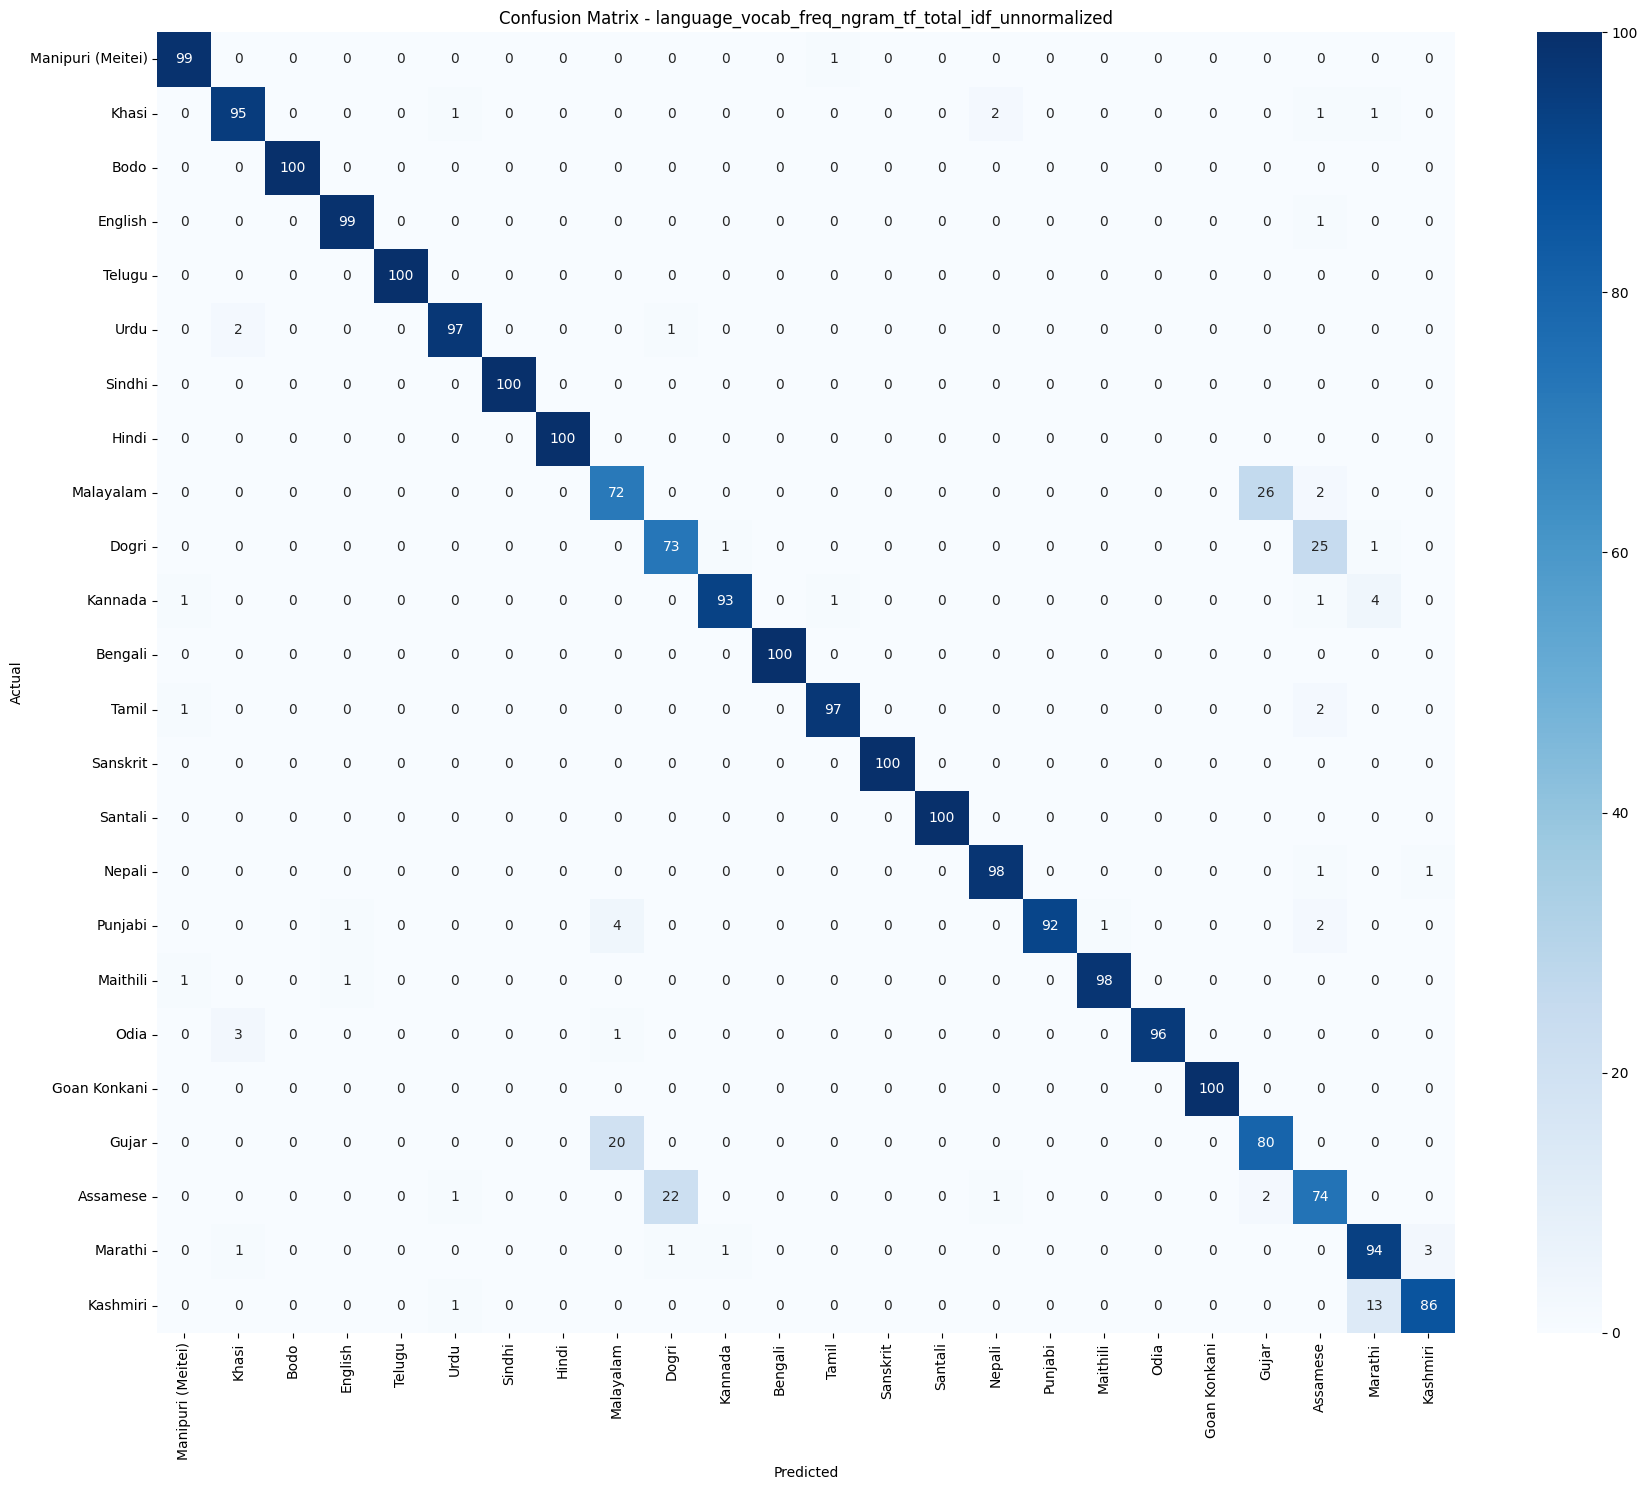

Evaluation saved to: D:/LLM/LAB 2/tfidf/full vocab\tf_total_idf_unnormalized\evaluation.csv
Model saved to: D:/LLM/LAB 2/tfidf/full vocab\tf_total_idf_unnormalized\model.pkl


WORKING ON: language_vocab_freq_ngram_tf_total_idf_normalized
Train shape: (19200, 2)
Validation shape: (2400, 2)
Test shape: (2400, 2)
Vocabulary size: 457668
Epoch 1/100, Training Loss = 3.1927, Validation Loss = 3.1867
Epoch 11/100, Training Loss = 3.0495, Validation Loss = 3.0541
Epoch 21/100, Training Loss = 2.9159, Validation Loss = 2.9226
Epoch 31/100, Training Loss = 2.7859, Validation Loss = 2.7945
Epoch 41/100, Training Loss = 2.6600, Validation Loss = 2.6704
Epoch 51/100, Training Loss = 2.5384, Validation Loss = 2.5506
Epoch 61/100, Training Loss = 2.4215, Validation Loss = 2.4354
Epoch 71/100, Training Loss = 2.3095, Validation Loss = 2.3250
Epoch 81/100, Training Loss = 2.2026, Validation Loss = 2.2197
Epoch 91/100, Training Loss = 2.1010, Validation Loss = 2.1195
Epoch 100/100, Training Loss = 2.01

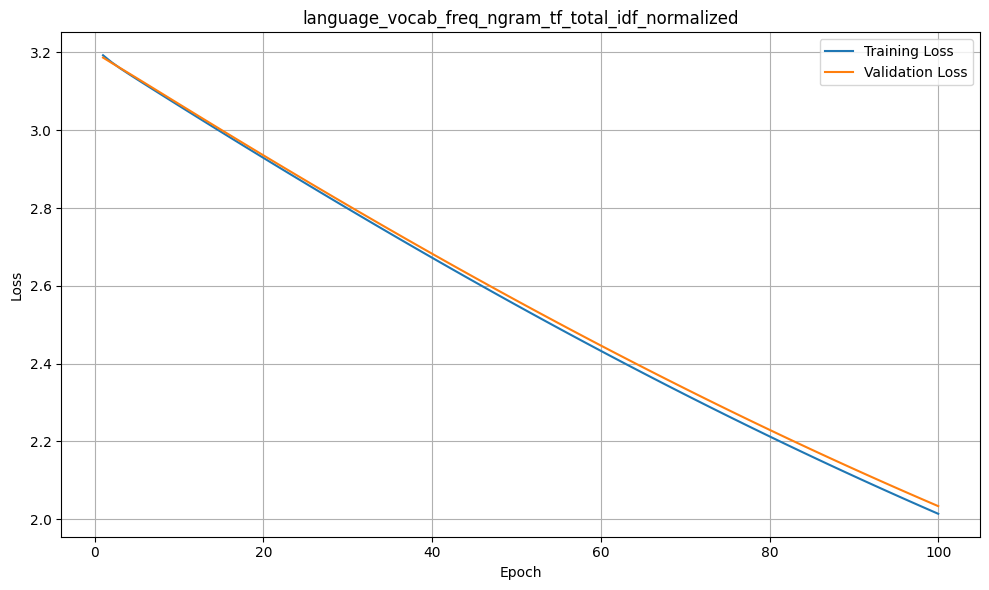

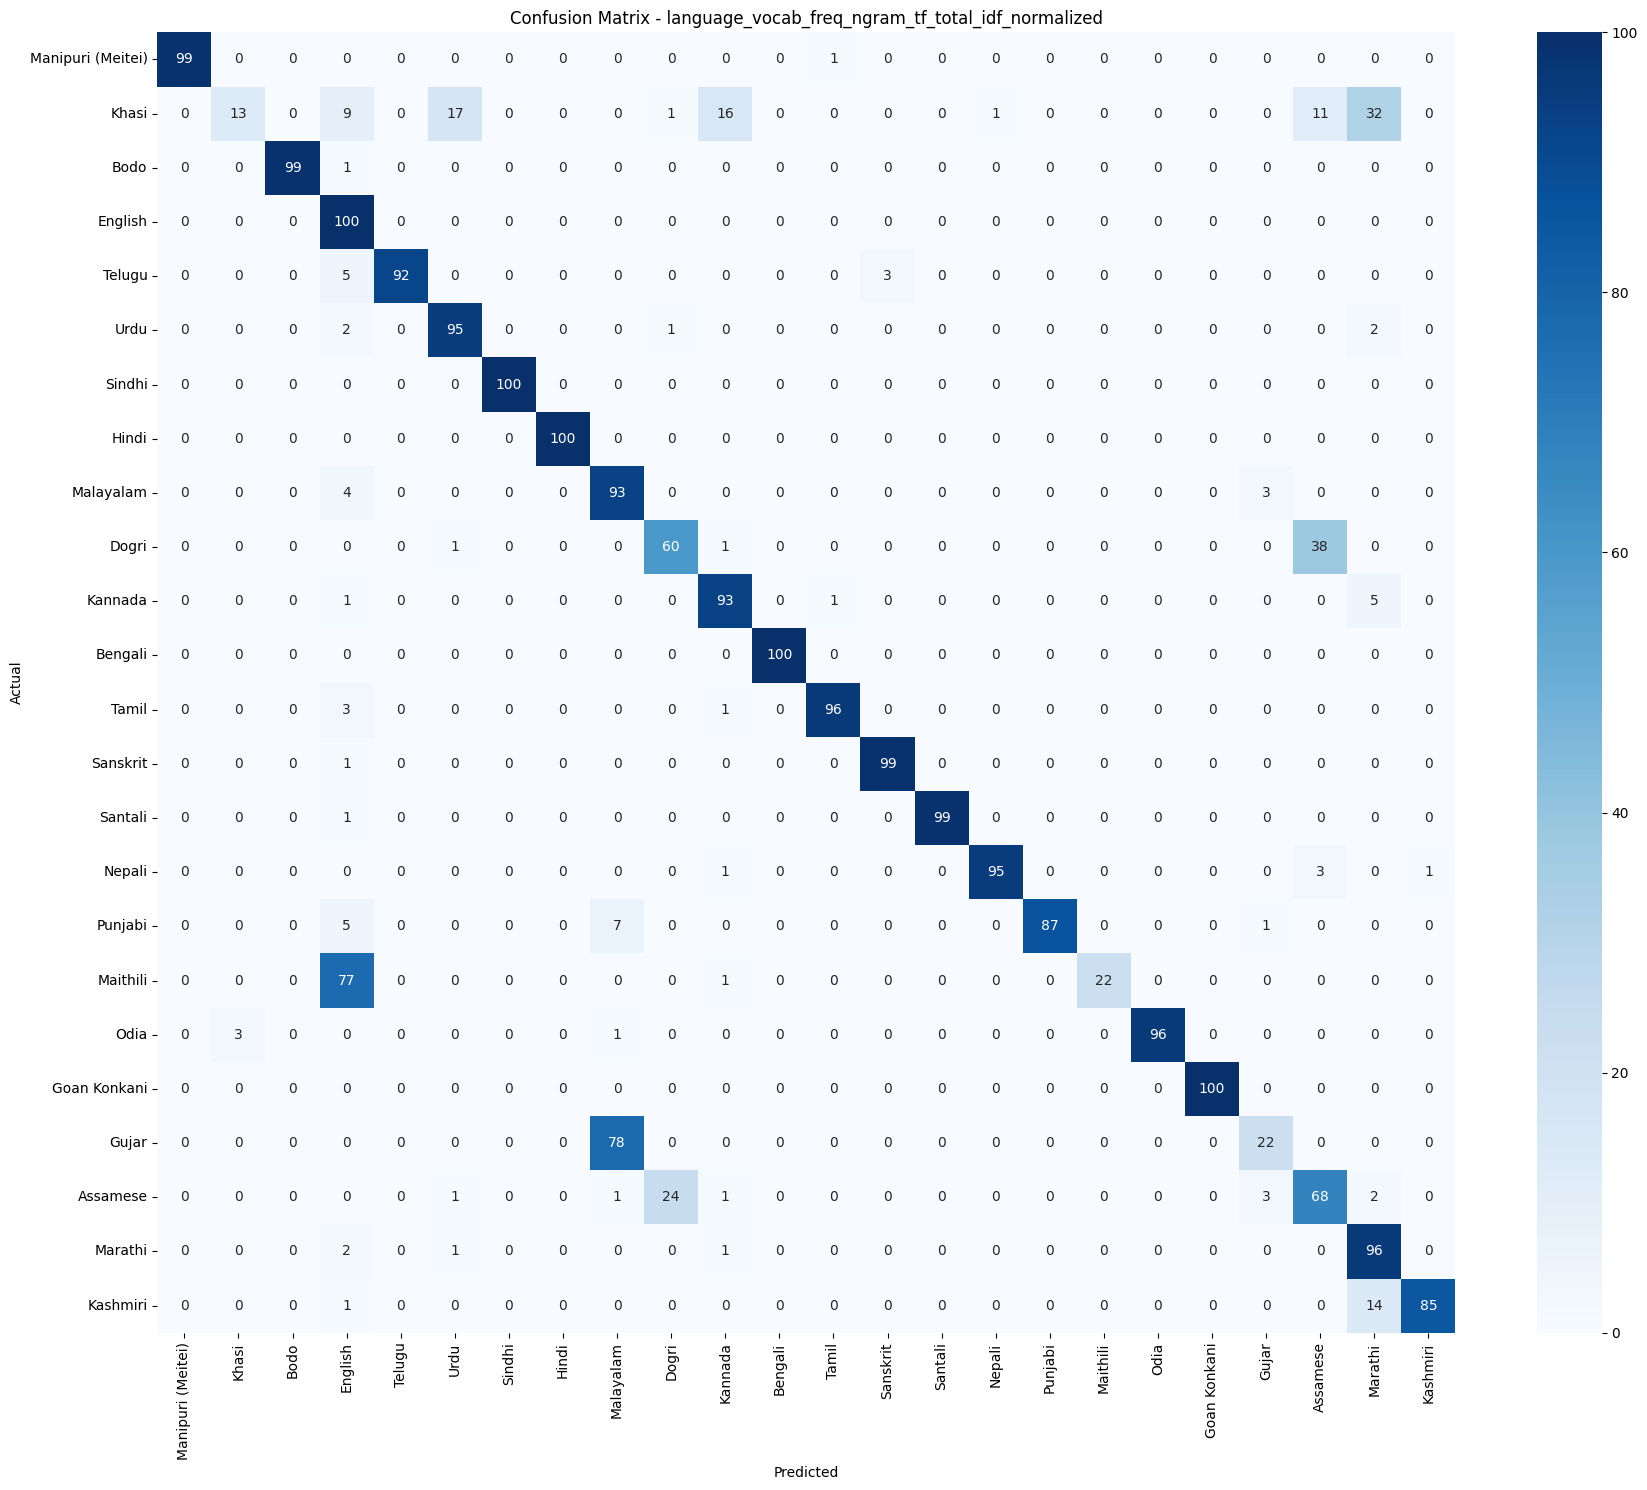

Evaluation saved to: D:/LLM/LAB 2/tfidf/full vocab\tf_total_idf_normalized\evaluation.csv
Model saved to: D:/LLM/LAB 2/tfidf/full vocab\tf_total_idf_normalized\model.pkl


WORKING ON: language_vocab_freq_ngram_tf_max_idf_unnormalized
Train shape: (19200, 2)
Validation shape: (2400, 2)
Test shape: (2400, 2)
Vocabulary size: 457668
Epoch 1/100, Training Loss = 0.8971, Validation Loss = 0.7868
Epoch 11/100, Training Loss = 0.0202, Validation Loss = 0.7285
Epoch 21/100, Training Loss = 0.0199, Validation Loss = 0.7335
Epoch 31/100, Training Loss = 0.0198, Validation Loss = 0.7353
Epoch 41/100, Training Loss = 0.0198, Validation Loss = 0.7365
Epoch 51/100, Training Loss = 0.0197, Validation Loss = 0.7376
Epoch 61/100, Training Loss = 0.0197, Validation Loss = 0.7384
Epoch 71/100, Training Loss = 0.0197, Validation Loss = 0.7391
Epoch 81/100, Training Loss = 0.0197, Validation Loss = 0.7398
Epoch 91/100, Training Loss = 0.0197, Validation Loss = 0.7404
Epoch 100/100, Training Loss = 0.0197, 

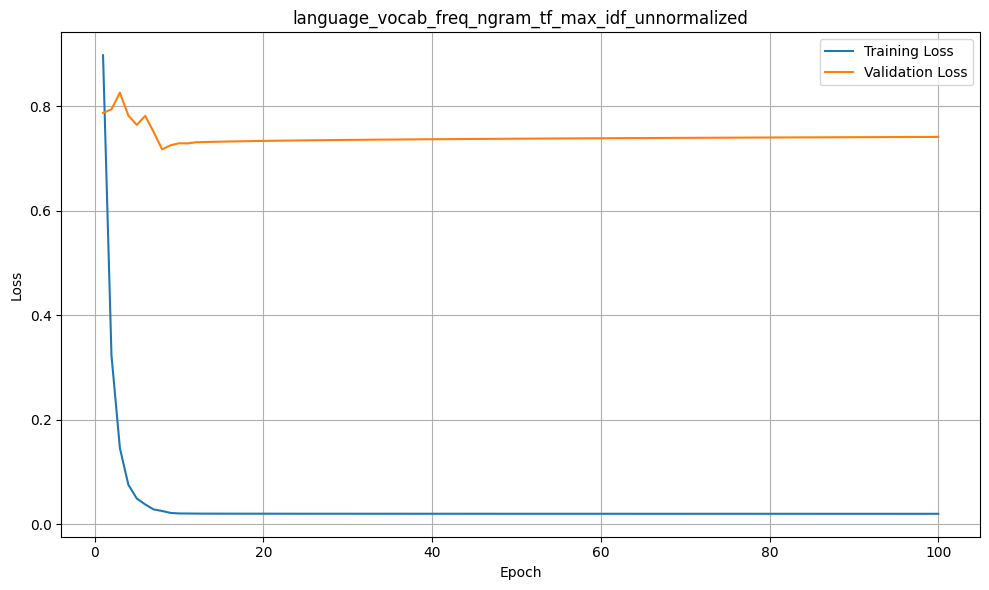

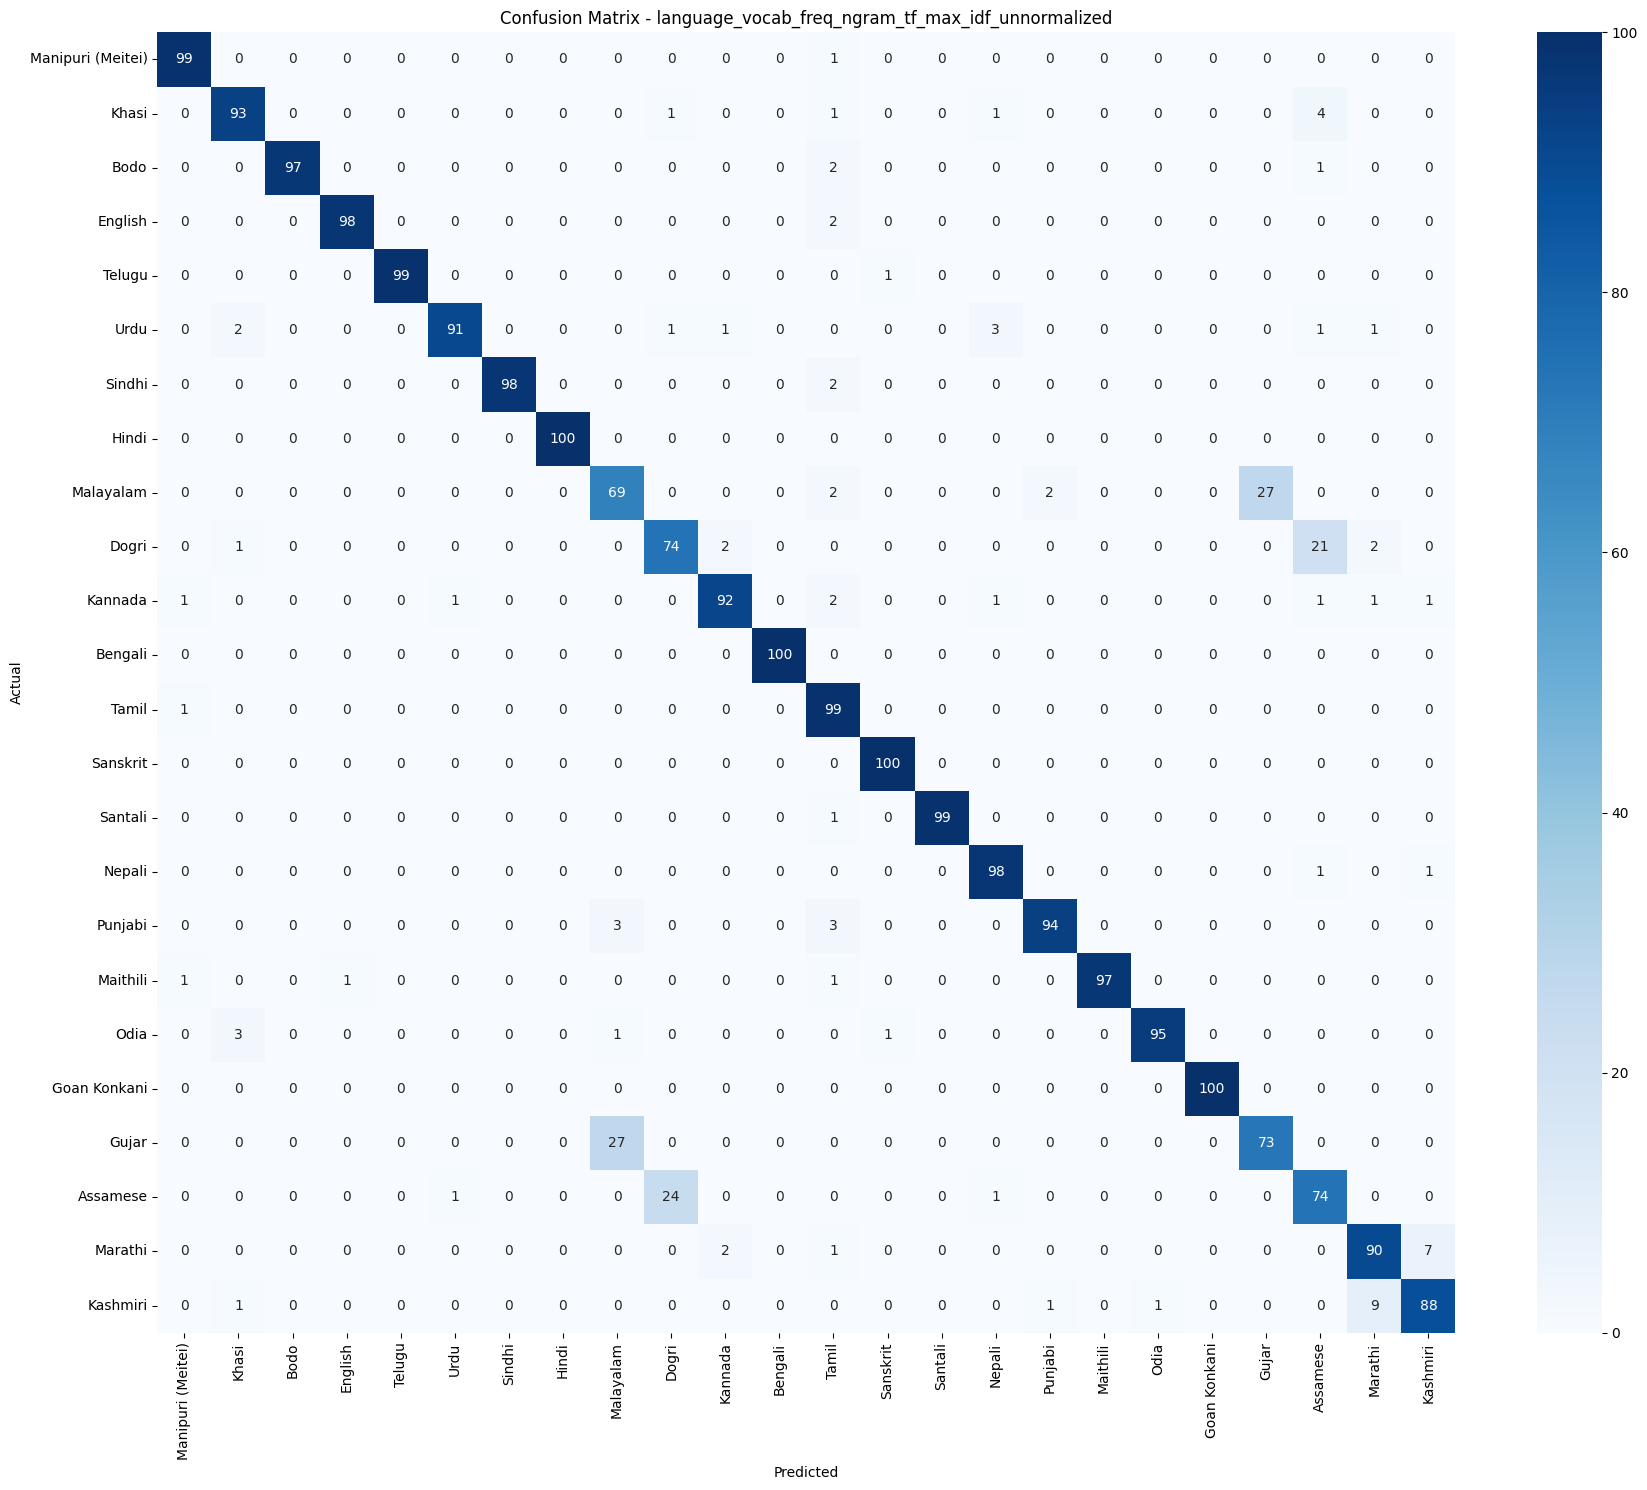

Evaluation saved to: D:/LLM/LAB 2/tfidf/full vocab\tf_max_idf_unnormalized\evaluation.csv
Model saved to: D:/LLM/LAB 2/tfidf/full vocab\tf_max_idf_unnormalized\model.pkl


WORKING ON: language_vocab_freq_ngram_tf_max_idf_normalized
Train shape: (19200, 2)
Validation shape: (2400, 2)
Test shape: (2400, 2)
Vocabulary size: 457668
Epoch 1/100, Training Loss = 0.9162, Validation Loss = 0.4633
Epoch 11/100, Training Loss = 0.1271, Validation Loss = 0.2132
Epoch 21/100, Training Loss = 0.0816, Validation Loss = 0.1938
Epoch 31/100, Training Loss = 0.0615, Validation Loss = 0.1874
Epoch 41/100, Training Loss = 0.0500, Validation Loss = 0.1850
Epoch 51/100, Training Loss = 0.0424, Validation Loss = 0.1842
Epoch 61/100, Training Loss = 0.0371, Validation Loss = 0.1843
Epoch 71/100, Training Loss = 0.0331, Validation Loss = 0.1849
Epoch 81/100, Training Loss = 0.0301, Validation Loss = 0.1858
Epoch 91/100, Training Loss = 0.0276, Validation Loss = 0.1869
Epoch 100/100, Training Loss = 0.0258, Va

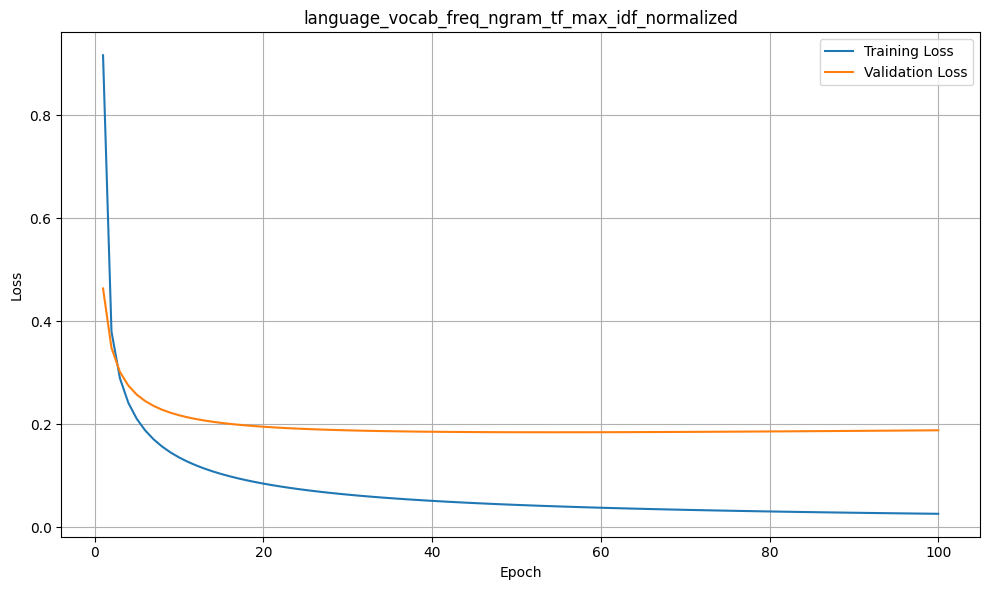

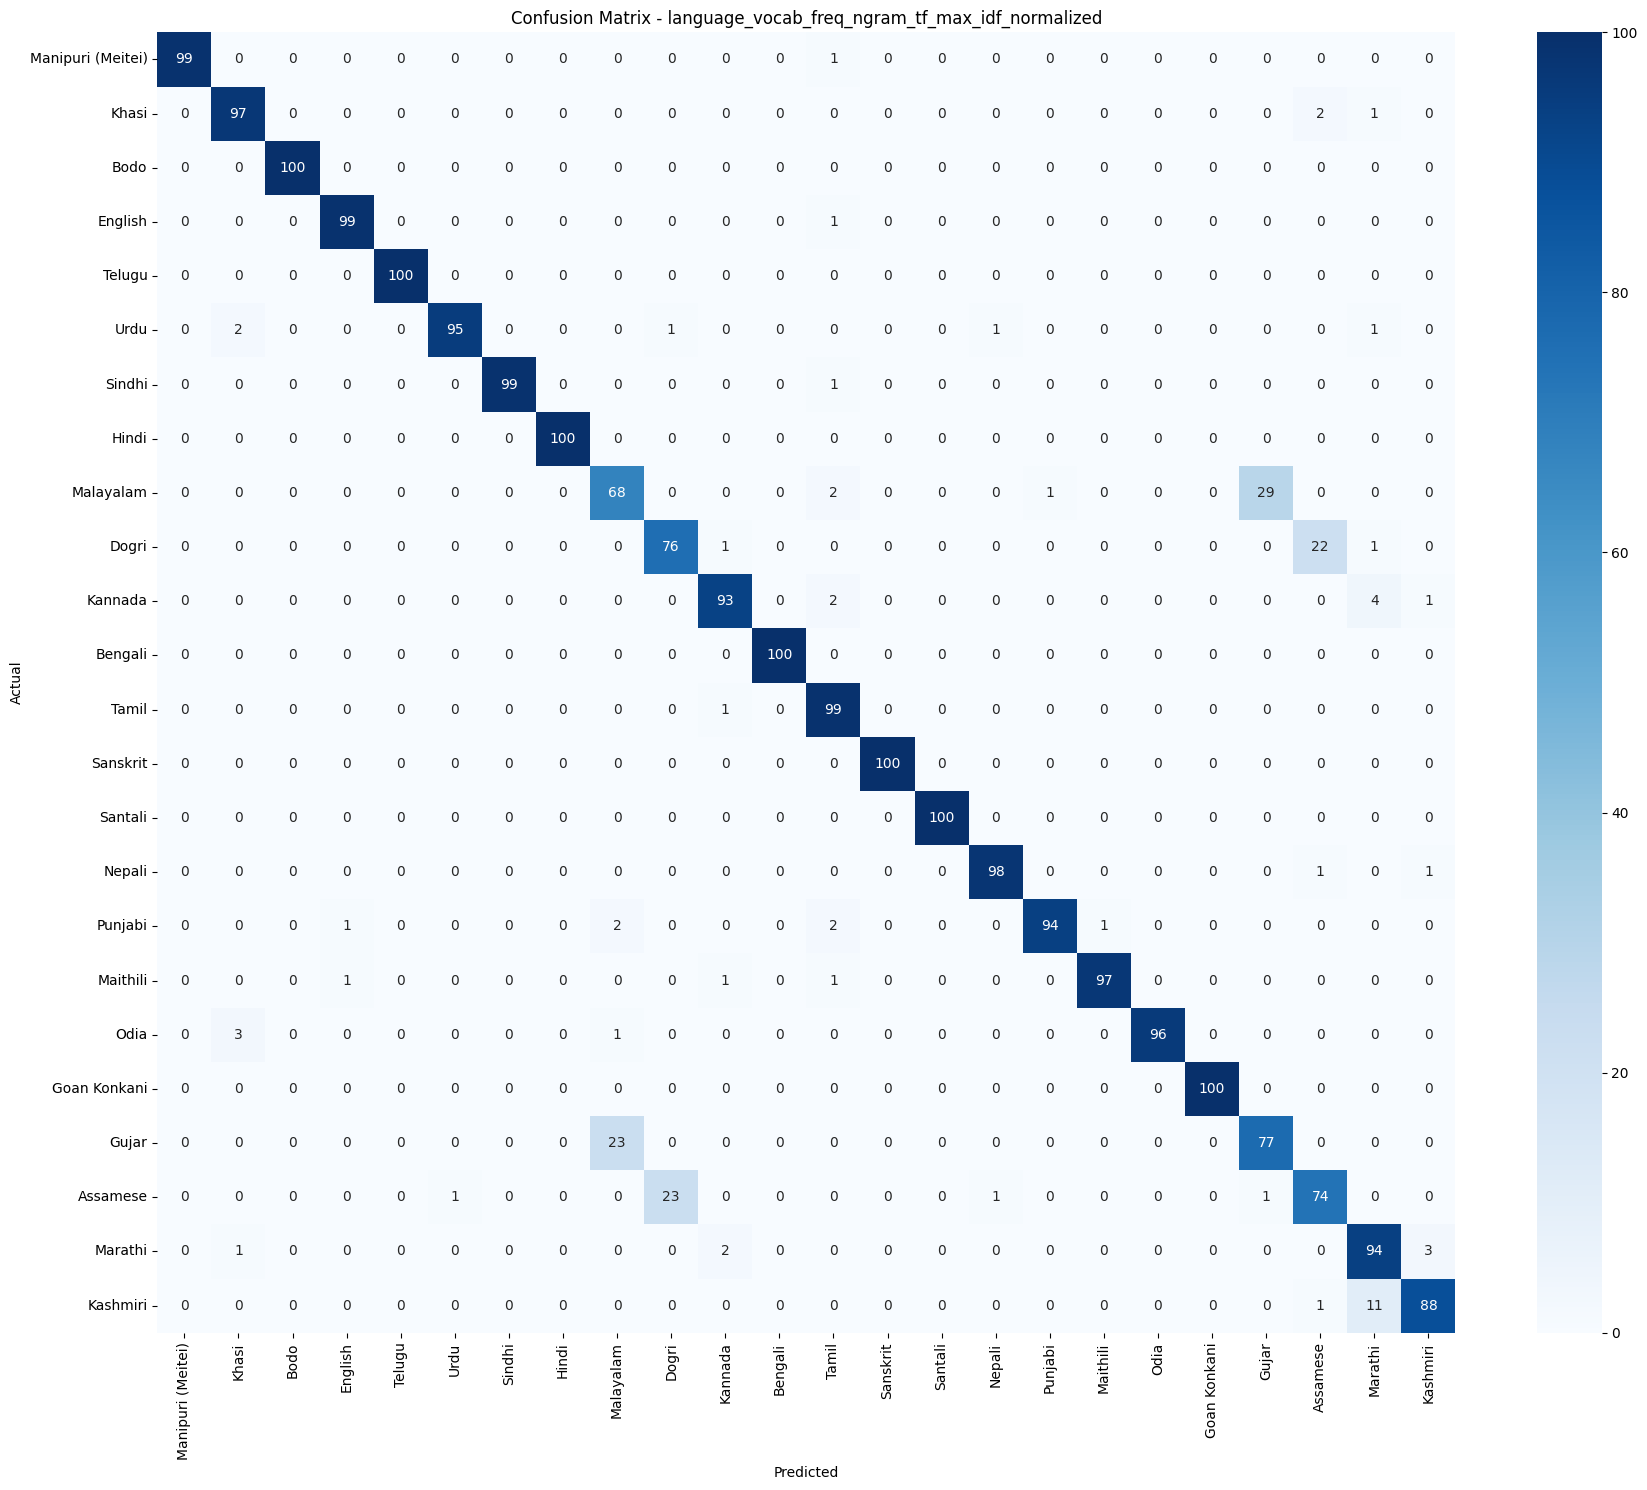

Evaluation saved to: D:/LLM/LAB 2/tfidf/full vocab\tf_max_idf_normalized\evaluation.csv
Model saved to: D:/LLM/LAB 2/tfidf/full vocab\tf_max_idf_normalized\model.pkl


FINAL SUMMARY
               vocab_type                tfidf_combination  accuracy  precision   recall       f1
language_vocab_freq_ngram tf_unnormalized_idf_unnormalized  0.920417   0.921807 0.920417 0.920721
language_vocab_freq_ngram   tf_unnormalized_idf_normalized  0.921250   0.923139 0.921250 0.921597
language_vocab_freq_ngram        tf_total_idf_unnormalized  0.934583   0.936759 0.934583 0.935191
language_vocab_freq_ngram          tf_total_idf_normalized  0.837083   0.875938 0.837083 0.820621
language_vocab_freq_ngram          tf_max_idf_unnormalized  0.923750   0.925183 0.923750 0.924072
language_vocab_freq_ngram            tf_max_idf_normalized  0.934583   0.935691 0.934583 0.934751


Summary saved to:
D:/LLM/LAB 2/tfidf\language_vocab_freq_ngram_model_summary.csv


BEST MODEL
Combination: tf_total_idf_unnormaliz

In [6]:
base_dir = r"D:/LLM/LAB 2/tfidf"
vocab_file = r"D:/LLM/LAB 1/Dataset/vocab/metadata/language_vocab_freq_ngram.pkl"

vocab_type = os.path.splitext(os.path.basename(vocab_file))[0]

vocab_dir =r"D:/LLM/LAB 2/tfidf/full vocab"

print("Vocabulary file:",vocab_file)
print("Vocabulary type:",vocab_type)
print("TF-IDF directory:",vocab_dir)

combination_names = ["tf_unnormalized_idf_unnormalized","tf_unnormalized_idf_normalized","tf_total_idf_unnormalized","tf_total_idf_normalized","tf_max_idf_unnormalized","tf_max_idf_normalized"]


all_results = []


for combination_name in combination_names:

    combination_dir = os.path.join(vocab_dir,combination_name)

    if not os.path.isdir(combination_dir):
        print(f"\nSkipping missing folder:")
        print(combination_dir)
        continue

    result = make_model(combination_dir=combination_dir,combination_name=f"{vocab_type}_{combination_name}",type="unnormalized",epochs=100,learning_rate=0.1)
    result["vocab_type"] = vocab_type
    result["tfidf_combination"] = combination_name
    all_results.append(result)


summary_df = pd.DataFrame(
    all_results
)

summary_df = summary_df[["vocab_type","tfidf_combination","accuracy","precision","recall","f1"]]
summary_path = os.path.join(base_dir,f"{vocab_type}_model_summary.csv")
summary_df.to_csv(summary_path,index=False)


print("\n")
print("=" * 100)
print("FINAL SUMMARY")
print("=" * 100)

print(summary_df.to_string(index=False))    
print("\n")
print("Summary saved to:")
print(summary_path)

best_model = summary_df.loc[
    summary_df["accuracy"].idxmax()
]


print("\n")
print("=" * 100)
print("BEST MODEL")
print("=" * 100)

print("Combination:",best_model["tfidf_combination"])
print("Accuracy:",best_model["accuracy"])
print("Precision:",best_model["precision"])
print("Recall:",best_model["recall"])
print("F1:",best_model["f1"])